# 📊 중개사 신뢰도 모델 분석 리포트

이 노트북은 학습된 모델(로지스틱 회귀)의 성능과 특성을 시각적으로 분석하기 위해 작성되었습니다.

### 분석 항목
1. **📉 학습 곡선 (Learning Curve)**: 과적합 여부 확인
2. **🔲 혼동 행렬 (Confusion Matrix)**: 등급별 예측 정확도 및 오분류 패턴
3. **📊 피처 중요도 (Coefficients)**: 모델이 어떤 변수를 중요하게 봤는지
4. **📈 ROC-AUC 곡선**: 클래스별 분류 성능
5. **🐝 SHAP 분석**: 모델의 판단 근거 상세 분석

In [1]:
# 1. 환경 설정 및 데이터 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 맞추기
current_path = os.getcwd()
if 'trust_model' in current_path:
    if 'SKN18-FINAL-1TEAM' in current_path:
         while not current_path.endswith('SKN18-FINAL-1TEAM'):
            current_path = os.path.dirname(current_path)
            if len(current_path) < 5: break
         os.chdir(current_path)
    print(f"📂 작업 디렉토리 변경: {os.getcwd()}")
else:
    print(f"ℹ️ 현재 작업 디렉토리: {os.getcwd()}")

# 데이터 경로 설정
X_TRAIN_PATH = "data/ML/trust/X_train.csv"
X_TEST_PATH = "data/ML/trust/X_test.csv"
Y_TRAIN_PATH = "data/ML/trust/y_train.csv"
Y_TEST_PATH = "data/ML/trust/y_test.csv"
MODEL_PATH = "apps/reco/models/trust_model/save_models/temp_trained_models.pkl"

# 데이터 로드 함수
def load_data():
    X_train = pd.read_csv(X_TRAIN_PATH, encoding="utf-8-sig")
    X_test = pd.read_csv(X_TEST_PATH, encoding="utf-8-sig")
    y_train = pd.read_csv(Y_TRAIN_PATH, encoding="utf-8-sig").squeeze()
    y_test = pd.read_csv(Y_TEST_PATH, encoding="utf-8-sig").squeeze()
    
    # [중요] 학습에 사용된 14개 피처 명시 (Leakage 방지)
    valid_features = [
        "등록매물_log", "총거래활동량_log", "1인당_거래량_log", 
        "총_직원수", "중개보조원_비율", "자격증_보유비율", 
        "운영기간_년", "숙련도_지수", "운영_안정성", 
        "대형사무소", "대표_공인중개사", "대표_법인", 
        "지역_경쟁강도", "1층_여부"
    ]
    
    # 실제 파일에 존재하는 컬럼만 선택
    final_features = [col for col in valid_features if col in X_train.columns]
    
    X_train = X_train[final_features]
    X_test = X_test[final_features]
    
    return X_train, X_test, y_train, y_test, final_features

if not os.path.exists(X_TRAIN_PATH):
    print("⚠️ 데이터 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    X_train, X_test, y_train, y_test, feature_names = load_data()
    
    # 전체 데이터 결합 (Learning Curve용)
    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)
    
    print("\n✅ 데이터 로드 완료")
    print(f"  - X shape: {X.shape}")
    print(f"  - 사용된 피처 수: {len(feature_names)}")
    print(f"  - 피처 목록: {feature_names}")
    print(f"  - y class distribution: {y.value_counts().to_dict()}")


📂 작업 디렉토리 변경: c:\dev\study\eunjeong\SKN18-FINAL-1TEAM

✅ 데이터 로드 완료
  - X shape: (351, 14)
  - 사용된 피처 수: 14
  - 피처 목록: ['등록매물_log', '총거래활동량_log', '1인당_거래량_log', '총_직원수', '중개보조원_비율', '자격증_보유비율', '운영기간_년', '숙련도_지수', '운영_안정성', '대형사무소', '대표_공인중개사', '대표_법인', '지역_경쟁강도', '1층_여부']
  - y class distribution: {1: 148, 2: 104, 0: 99}


📊 학습 곡선 생성 중...


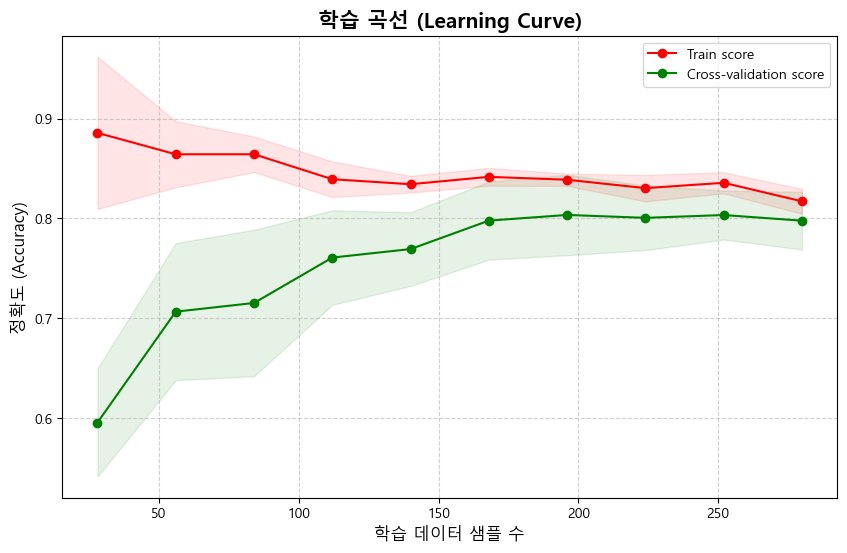

➕ 해석 Point: Train(Red)과 CV(Green) 곡선이 서로 비슷한 높이로 수렴해야 과적합이 없는 것입니다.


In [2]:
# 2. 📉 학습 곡선 (Learning Curve)
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 최신 모델 설정 (C=1, penalty='l1', solver='saga')
best_model = LogisticRegression(
    C=1, 
    penalty='l1', 
    solver='saga', 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42
)

# 파이프라인 구성
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('clf', best_model)
])

print("📊 학습 곡선 생성 중...")
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Train score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("학습 곡선 (Learning Curve)", fontsize=15, fontweight='bold')
plt.xlabel("학습 데이터 샘플 수", fontsize=12)
plt.ylabel("정확도 (Accuracy)", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("➕ 해석 Point: Train(Red)과 CV(Green) 곡선이 서로 비슷한 높이로 수렴해야 과적합이 없는 것입니다.")


📊 모델 학습 중...


c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


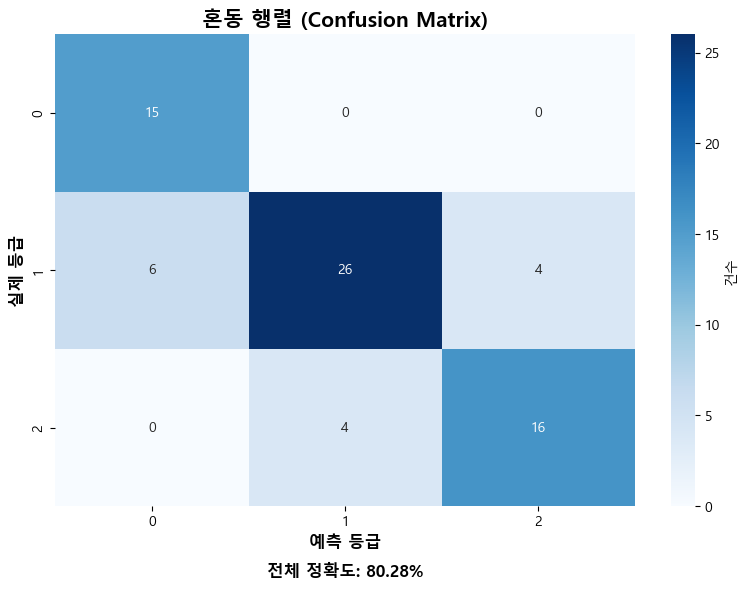

➕ 해석 Point: 대각선(진한 색)에 숫자가 많을수록 좋습니다.


In [3]:
# 3. 🔲 혼동 행렬 (Confusion Matrix)
from sklearn.metrics import confusion_matrix

# 모델 학습
print("📊 모델 학습 중...")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': '건수'})

plt.title('혼동 행렬 (Confusion Matrix)', fontsize=15, fontweight='bold')
plt.xlabel('예측 등급', fontsize=12, fontweight='bold')
plt.ylabel('실제 등급', fontsize=12, fontweight='bold')

# 정확도 표시
accuracy = np.trace(cm) / np.sum(cm)
plt.text(0.5, -0.15, f'전체 정확도: {accuracy:.2%}', 
        ha='center', transform=plt.gca().transAxes, 
        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("➕ 해석 Point: 대각선(진한 색)에 숫자가 많을수록 좋습니다.")


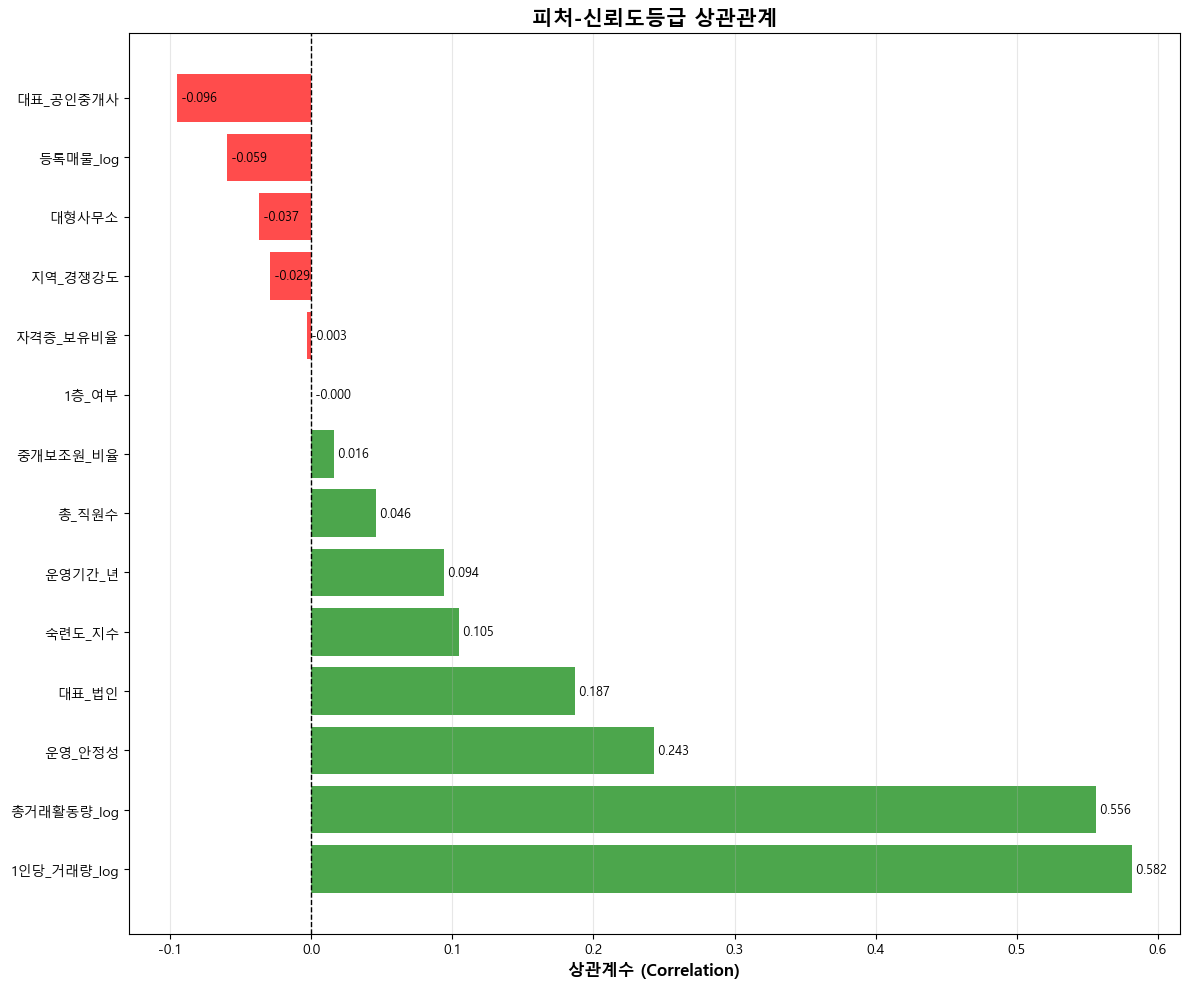

In [4]:
# 4. 📊 피처-타겟 상관관계 분석
target_map = {'A': 2, 'B': 1, 'C': 0}
if y.dtype == object:
    y_encoded = y.map(target_map)
else:
    y_encoded = y

df_corr = X.copy()
df_corr['Target'] = y_encoded

corr_matrix = df_corr.corr()
target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=False)

plt.figure(figsize=(12, 10))
# 색상: 양의 상관관계(초록), 음의 상관관계(빨강)
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
plt.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(target_corr)), target_corr.index)
plt.xlabel('상관계수 (Correlation)', fontsize=12, fontweight='bold')
plt.title('피처-신뢰도등급 상관관계', fontsize=15, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(target_corr.values):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


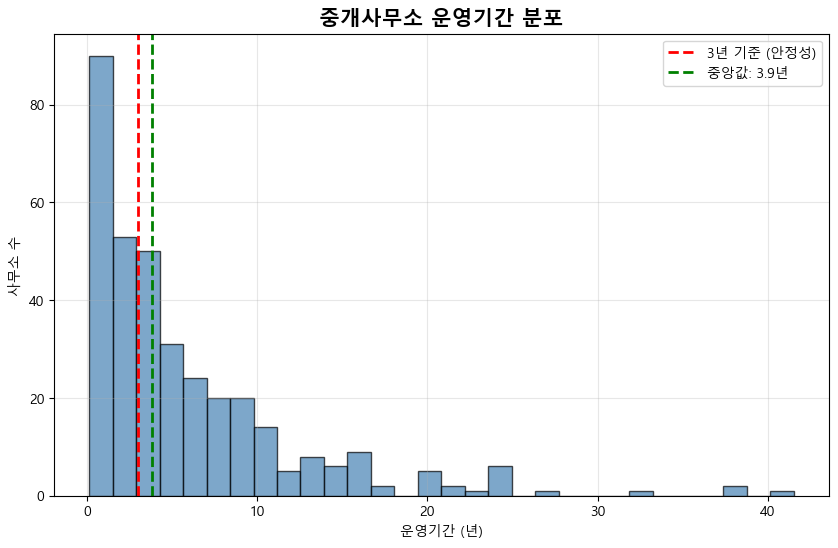

📊 평균 운영기간: 5.90년, 중앙값: 3.85년


In [5]:
# 5. 🏢 운영미간 분포 분석
TRAIN_TARGET_PATH = "data/ML/trust/train_target.csv"
TEST_TARGET_PATH = "data/ML/trust/test_target.csv"

df_train_orig = pd.read_csv(TRAIN_TARGET_PATH, encoding="utf-8-sig")
df_test_orig = pd.read_csv(TEST_TARGET_PATH, encoding="utf-8-sig")
df_target = pd.concat([df_train_orig, df_test_orig], ignore_index=True)

df_target['등록일'] = pd.to_datetime(df_target['등록일'], errors='coerce')
today = pd.Timestamp.now()
df_target['운영기간_일'] = (today - df_target['등록일']).dt.days.clip(lower=0)
df_target['운영기간_년'] = (df_target['운영기간_일'] / 365.25).fillna(0)

op_years = df_target['운영기간_년'].dropna()
median_years = op_years.median()
mean_years = op_years.mean()

plt.figure(figsize=(10, 6))
plt.hist(op_years, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(3, color='red', linestyle='--', linewidth=2, label='3년 기준 (안정성)')
plt.axvline(median_years, color='green', linestyle='--', linewidth=2, label=f'중앙값: {median_years:.1f}년')
plt.title('중개사무소 운영기간 분포', fontsize=15, fontweight='bold')
plt.xlabel('운영기간 (년)')
plt.ylabel('사무소 수')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"📊 평균 운영기간: {mean_years:.2f}년, 중앙값: {median_years:.2f}년")


📊 모델 계수 분석 시작...


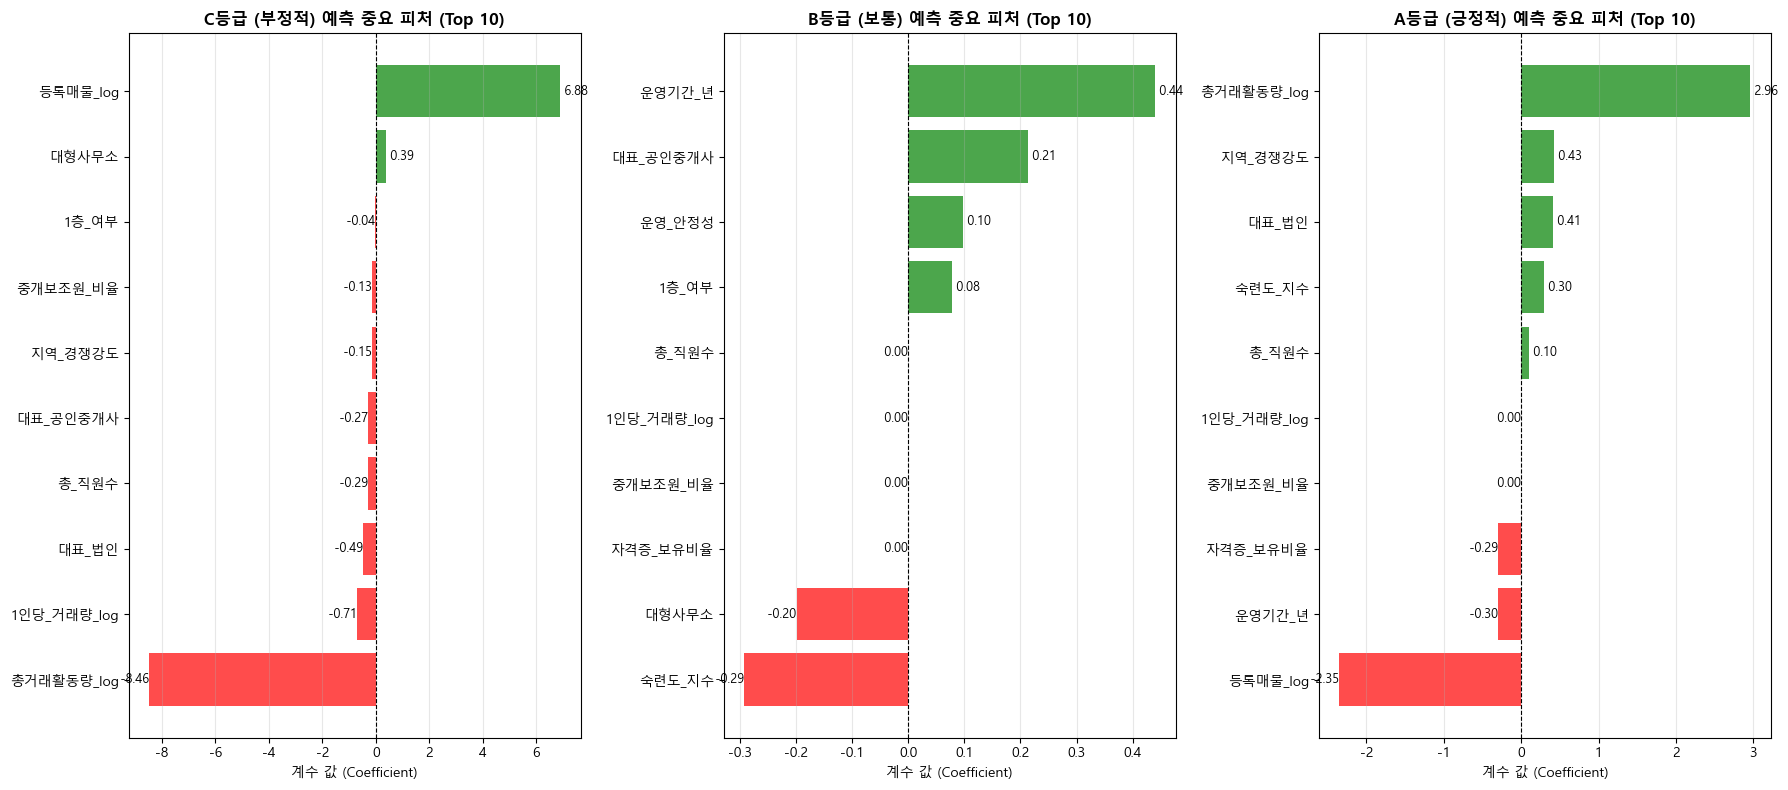

➕ 해석 Point:
   - 초록색(+) 막대: 이 값이 클수록 해당 등급일 확률이 높아집니다.
   - 빨간색(-) 막대: 이 값이 클수록 해당 등급일 확률이 낮아집니다.


In [7]:
# 6. 📊 모델 계수(Coefficient) 분석 - 방향성 확인
# Logistic Regression 모델의 계수를 통해 각 Class(등급)별로 어떤 피처가 
# 긍정적(+) 또는 부정적(-) 영향을 주는지 확인합니다.

if hasattr(best_model, 'coef_'):
    print("📊 모델 계수 분석 시작...")
    coeffs = best_model.coef_
    # label mapping: 0=C, 1=B, 2=A (확인 필요, 일반적인 순서 가정)
    # 모델 학습 시 classes_ 순서 확인
    classes = getattr(best_model, 'classes_', [0, 1, 2])
    
    # Class 별 이름 매핑 (수정 필요 시 변경)
    # 예: 0->C, 1->B, 2->A 
    class_map = {0: 'C등급 (부정적)', 1: 'B등급 (보통)', 2: 'A등급 (긍정적)'}
    
    n_classes = coeffs.shape[0]
    # 이진 분류일 경우 1개 행만 존재할 수 있음 -> 다중 분류 가정
    
    if n_classes == 1:
        # 이진 분류라면 (0 vs 1)
        print("ℹ️ 이진 분류 모델입니다.")
        rows = 1
        cols = 1
        fig, ax = plt.subplots(figsize=(10, 8))
        axes = [ax]
        plot_indices = [1] # 양성 클래스 기준
    else:
        # 다중 분류
        rows = 1
        cols = n_classes
        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 8), sharey=False)
        plot_indices = range(n_classes)

    for idx, class_idx in enumerate(plot_indices):
        ax = axes[idx] if n_classes > 1 else axes[0]
        
        # 해당 클래스의 계수
        if n_classes == 1:
            class_coeffs = coeffs[0] # 이진 분류는 하나만 있음
            title_text = "Positive Class Coefficients"
        else:
            class_coeffs = coeffs[idx]
            class_label = classes[idx]
            class_name = class_map.get(class_label, f'Class {class_label}')
            title_text = f"{class_name} 예측 중요 피처 (Top 10)"

        # DataFrame 생성
        coeff_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': class_coeffs
        })
        
        # 절대값 기준으로 상위 10개 선정 (방향성 포함)
        coeff_df['Abs_Coeff'] = coeff_df['Coefficient'].abs()
        top_10 = coeff_df.sort_values(by='Abs_Coeff', ascending=False).head(10)
        
        # 그래프 그리기 (원래 값인 Coefficient로 정렬하여 표시)
        top_10 = top_10.sort_values(by='Coefficient', ascending=True)
        
        # 색상 설정: 양수(초록), 음수(빨강)
        colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
        
        ax.barh(top_10['Feature'], top_10['Coefficient'], color=colors, alpha=0.7)
        ax.set_title(title_text, fontsize=12, fontweight='bold')
        ax.set_xlabel('계수 값 (Coefficient)', fontsize=10)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.grid(axis='x', alpha=0.3)
        
        # 값 텍스트 표시
        for i, v in enumerate(top_10['Coefficient']):
            ax.text(v, i, f' {v:.2f}', va='center', fontsize=9, 
                    ha='left' if v > 0 else 'right')

    plt.tight_layout()
    plt.show()
    
    print("➕ 해석 Point:")
    print("   - 초록색(+) 막대: 이 값이 클수록 해당 등급일 확률이 높아집니다.")
    print("   - 빨간색(-) 막대: 이 값이 클수록 해당 등급일 확률이 낮아집니다.")
else:
    print("⚠️ 선형 모델이 아니거나 계수(coef_) 속성이 없습니다.")


📊 모델 계수 분석 시작...


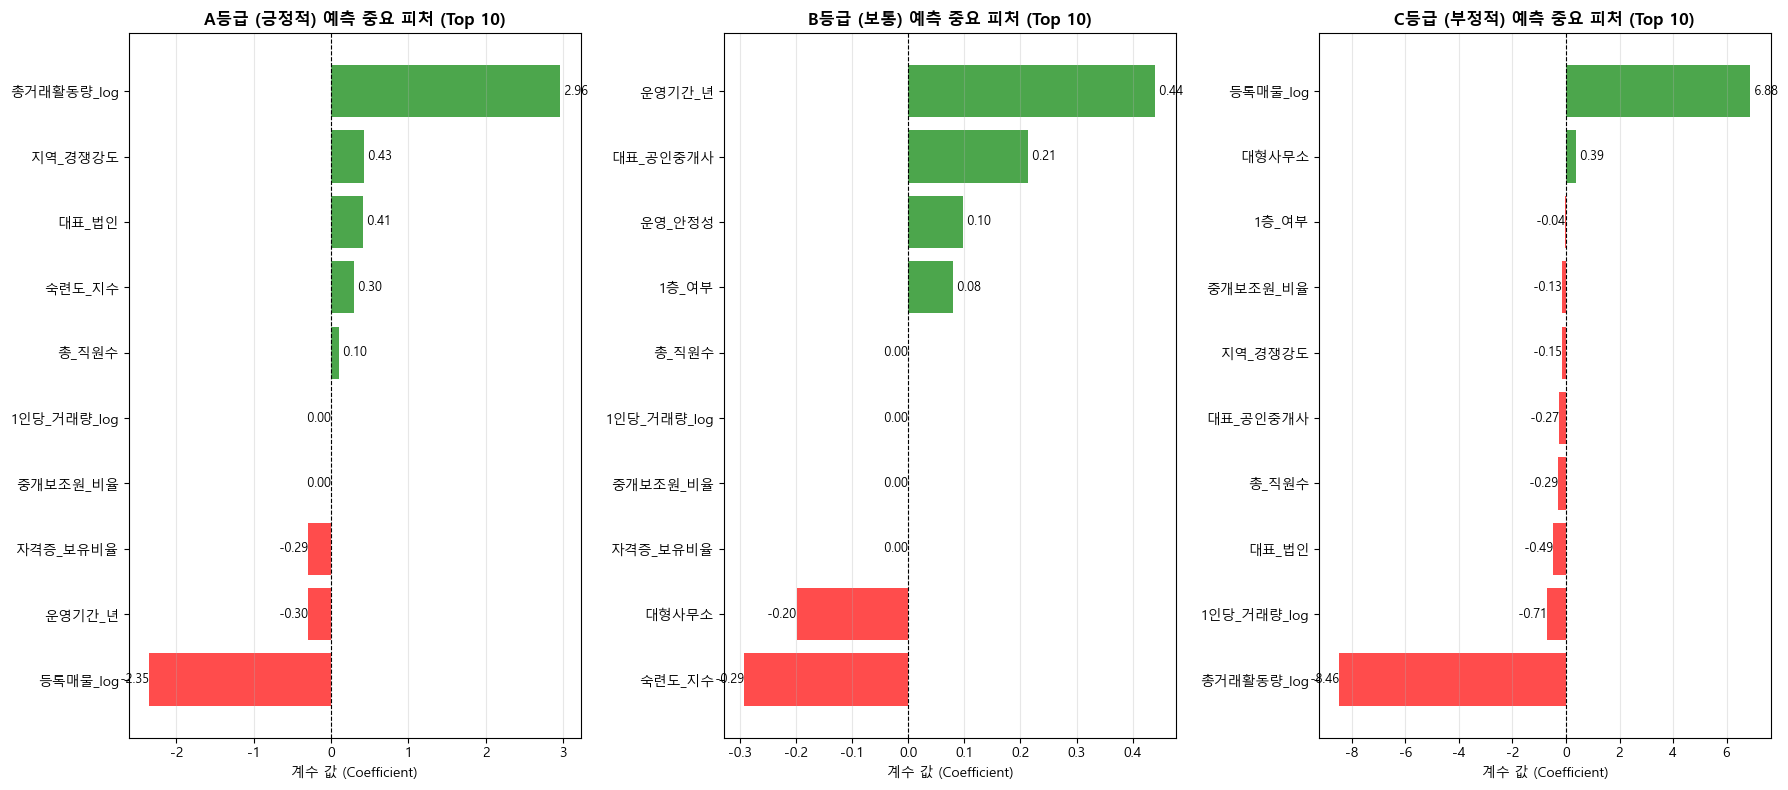


📋 [등급별 중요 피처 상세 수치 (Top 10)]


,Grade,Feature,Coefficient
0,A등급 (긍정적),총거래활동량_log,2.9604
1,A등급 (긍정적),등록매물_log,-2.3511
2,A등급 (긍정적),지역_경쟁강도,0.4303
3,A등급 (긍정적),대표_법인,0.4134
4,A등급 (긍정적),숙련도_지수,0.2995
5,A등급 (긍정적),운영기간_년,-0.2950
6,A등급 (긍정적),자격증_보유비율,-0.2934
7,A등급 (긍정적),총_직원수,0.0967
8,A등급 (긍정적),중개보조원_비율,0.0000
9,A등급 (긍정적),1인당_거래량_log,0.0000


In [8]:
# 6. 📊 모델 계수(Coefficient) 분석 - 방향성 확인 & 요약
# Logistic Regression 모델의 계수를 통해 각 Class(등급)별로 어떤 피처가 
# 긍정적(+) 또는 부정적(-) 영향을 주는지 확인합니다.

if hasattr(best_model, 'coef_'):
    print("📊 모델 계수 분석 시작...")
    coeffs = best_model.coef_
    classes = getattr(best_model, 'classes_', [0, 1, 2])
    
    # Class 매핑 및 순서 지정 (A -> B -> C 순서로 출력)
    # 실제 모델 클래스: 0(C), 1(B), 2(A) 가정
    class_map = {0: 'C등급 (부정적)', 1: 'B등급 (보통)', 2: 'A등급 (긍정적)'}
    
    # 원하는 출력 순서: A(2) -> B(1) -> C(0)
    # 만약 모델 클래스가 다르면 이 리스트를 수정해야 함
    target_order = [2, 1, 0]  
    
    # 해당 클래스가 실제 모델에 존재하는지 확인 후 필터링
    plot_indices = [c for c in target_order if c in classes]
    
    n_classes = len(plot_indices)
    
    # 1. 그래프 그리기
    if n_classes > 0:
        fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 8), sharey=False)
        if n_classes == 1: axes = [axes]
        
        # 각 등급별로 그래프 생성
        for split_idx, class_label in enumerate(plot_indices):
            ax = axes[split_idx]
            
            # 실제 coeffs 배열에서의 인덱스 찾기
            # classes_ 배열에서 class_label의 위치(인덱스)를 찾아야 함
            real_idx = list(classes).index(class_label)
            class_coeffs = coeffs[real_idx]
            
            class_name = class_map.get(class_label, f'Class {class_label}')
            title_text = f"{class_name} 예측 중요 피처 (Top 10)"

            # DataFrame 생성
            coeff_df = pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': class_coeffs
            })
            
            # 절대값 기준으로 상위 10개
            coeff_df['Abs_Coeff'] = coeff_df['Coefficient'].abs()
            top_10 = coeff_df.sort_values(by='Abs_Coeff', ascending=False).head(10)
            top_10 = top_10.sort_values(by='Coefficient', ascending=True)
            
            colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
            
            ax.barh(top_10['Feature'], top_10['Coefficient'], color=colors, alpha=0.7)
            ax.set_title(title_text, fontsize=12, fontweight='bold')
            ax.set_xlabel('계수 값 (Coefficient)', fontsize=10)
            ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
            ax.grid(axis='x', alpha=0.3)
            
            for i, v in enumerate(top_10['Coefficient']):
                ax.text(v, i, f' {v:.2f}', va='center', fontsize=9, 
                        ha='left' if v > 0 else 'right')

        plt.tight_layout()
        plt.show()
    
    # 2. 등급별 수치 표로 정리
    print("\n📋 [등급별 중요 피처 상세 수치 (Top 10)]")
    
    # 모든 등급의 데이터를 하나의 DataFrame으로 합치기
    summary_dfs = []
    
    for class_label in plot_indices:
        real_idx = list(classes).index(class_label)
        class_coeffs = coeffs[real_idx]
        class_name = class_map.get(class_label, f'{class_label}')
        
        # 전체 데이터
        full_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': class_coeffs,
            'Abs_Coeff': np.abs(class_coeffs)
        })
        # 상위 10개 추출
        top_10_df = full_df.sort_values(by='Abs_Coeff', ascending=False).head(10).copy()
        
        # 보기 좋게 포맷팅
        top_10_df['Grade'] = class_name
        top_10_df = top_10_df[['Grade', 'Feature', 'Coefficient']]
        summary_dfs.append(top_10_df)
    
    # 전체 결과 합치기
    if summary_dfs:
        final_table = pd.concat(summary_dfs, ignore_index=True)
        # 테이블 스타일링해서 출력 (Jupyter Notebook)
        from IPython.display import display
        display(final_table.style.bar(subset=['Coefficient'], align='mid', color=['#d65f5f', '#5fba7d'])
                           .format({'Coefficient': '{:.4f}'})
                           .set_properties(**{'text-align': 'center'}))
    else:
        print("표시할 데이터가 없습니다.")

else:
    print("⚠️ 선형 모델이 아니거나 계수(coef_) 속성이 없습니다.")



🔍 Starting SHAP Analysis...
   - Setting up SHAP Explainer (KernelExplainer)...
   - Calculating SHAP values (this may take a minute)...


  0%|          | 0/71 [00:00<?, ?it/s]


📊 Generating Plots...


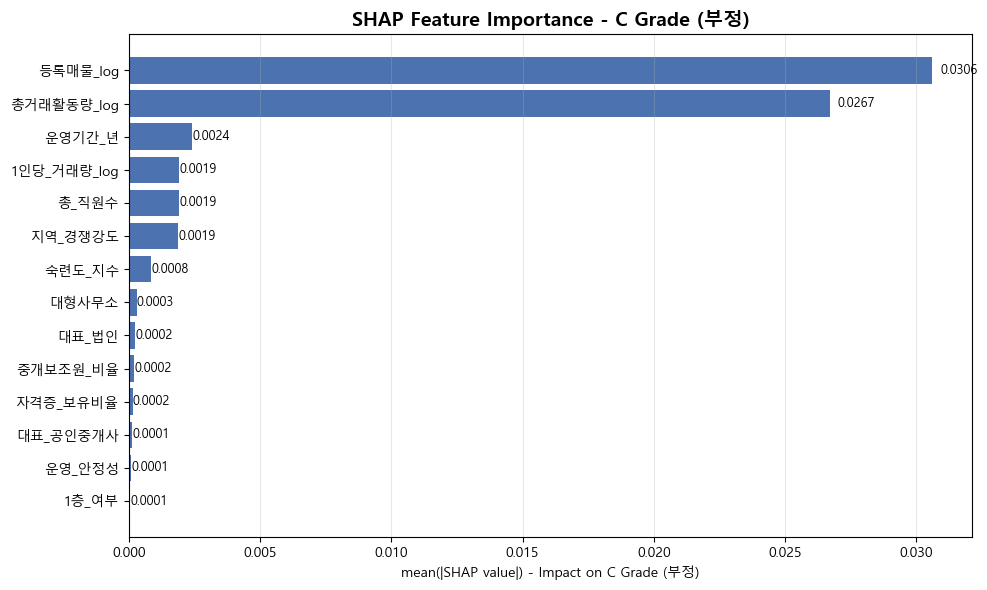

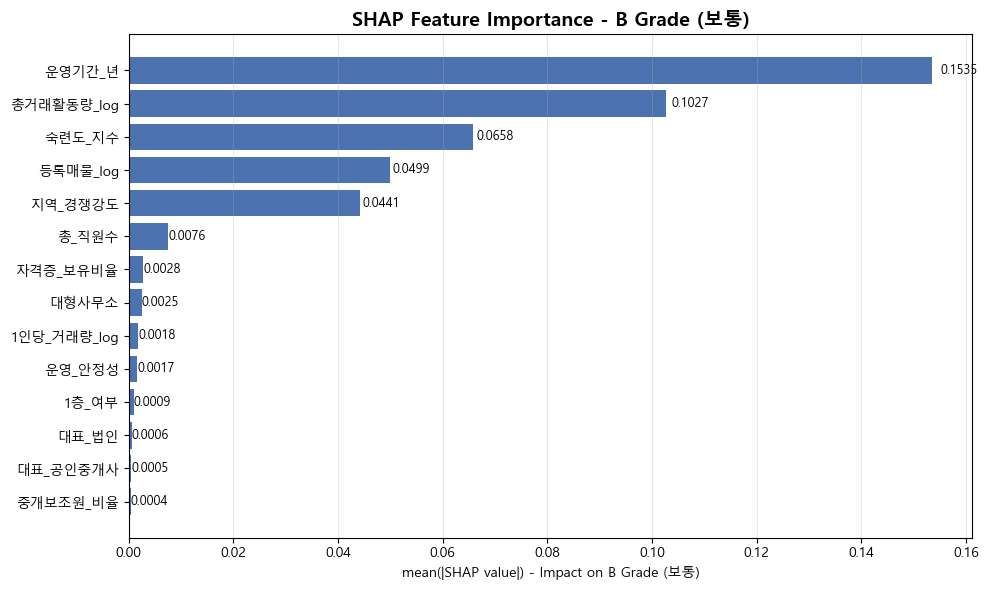

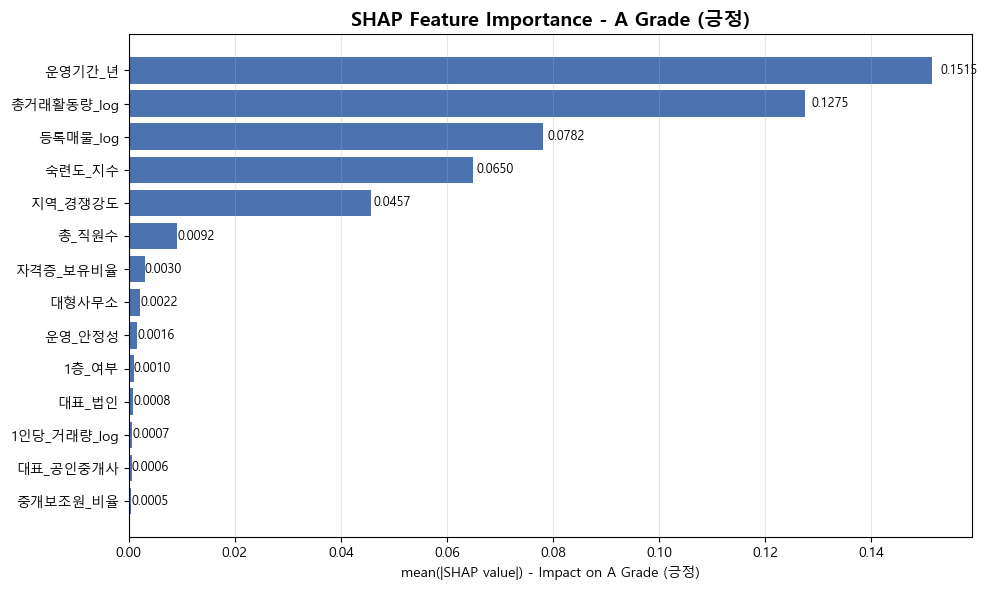

✅ SHAP Analysis Completed.


In [9]:

# 5. 🐝 SHAP Analysis (Feature Importance by Grade)
# -------------------------------------------------------------------------
# This analysis helps understand which features most influenced the model's decision for each grade.
# For A Grade (2), Positive coefficients indicate features that increase trust.
#
# (Note: This analysis uses the 'best_model' loaded previously)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n🔍 Starting SHAP Analysis...")

# 1. Prepare Data and Model
# Ensure we use the best_model and X_test loaded in previous cells
if 'best_model' not in locals():
    print("⚠️ 'best_model' not found. Please run the model loading cell first.")
else:
    # 2. Setup Explainer
    # For Logistic Regression (Linear Model), we use KernelExplainer with probability prediction
    # To speed up, we use a sample of the background data (X_test)
    
    print("   - Setting up SHAP Explainer (KernelExplainer)...")
    
    # Use a small background sample for speed (e.g., 50 samples)
    if hasattr(best_model, 'steps'):
        # If pipeline, we need to handle preprocessing
        # But for simplicity in notebook, if X_test is already preprocessed or similar, we might need care.
        # Assuming X_test loaded in previous cell is raw data, and model has pipeline.
        # To avoid complex pipeline matching, we pass the full predict_proba function.
        predictor = best_model.predict_proba
        masker = shap.sample(X_test, 50) # use 50 random samples as background
    else:
        predictor = best_model.predict_proba
        masker = shap.sample(X_test, 50)

    # Initialize Explainer
    explainer = shap.KernelExplainer(predictor, masker)

    # 3. Calculate SHAP Values
    print("   - Calculating SHAP values (this may take a minute)...")
    # Calculate for a subset of test data to save time (e.g., 100 samples)
    X_shap_sample = X_test.sample(n=min(100, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(X_shap_sample)

    # 4. Process and Plot for Each Class (0:C, 1:B, 2:A)
    # Class mapping
    class_map = {0: 'C Grade (부정)', 1: 'B Grade (보통)', 2: 'A Grade (긍정)'}
    
    # Handle SHAP values structure (list of arrays for multiclass)
    if isinstance(shap_values, list):
        shap_data = shap_values
    else:
        # If not list, might be array (samples, features, classes) - convert to list
        shap_data = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

    print("\n📊 Generating Plots...")
    
    for i, class_shap_values in enumerate(shap_data):
        class_label = explainer.model.classes_[i] if hasattr(explainer.model, 'classes_') else i
        class_name = class_map.get(class_label, f'Class {class_label}')
        
        # Calculate mean absolute SHAP value for importance
        mean_shap = np.abs(class_shap_values).mean(axis=0)
        
        # Create DataFrame for plotting
        df_imp = pd.DataFrame({
            'Feature': X_test.columns,
            'Importance': mean_shap
        }).sort_values('Importance', ascending=True)
        
        # Select top 10 features
        # df_imp = df_imp.tail(10)
        
        # Plot
        plt.figure(figsize=(10, 6))
        bars = plt.barh(df_imp['Feature'], df_imp['Importance'], color='#4c72b0')
        plt.title(f'SHAP Feature Importance - {class_name}', fontsize=14, fontweight='bold')
        plt.xlabel(f'mean(|SHAP value|) - Impact on {class_name}')
        plt.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            plt.text(width*1.01, bar.get_y() + bar.get_height()/2, 
                     f'{width:.4f}', ha='left', va='center', fontsize=9)
            
        plt.tight_layout()
        plt.show()

print("✅ SHAP Analysis Completed.")
